<a name="top" id="top"></a>

<div align="center">
    <h1>Introduction to Mathematical Programming</h1>
    <a href="https://github.com/bernalde">David E. Bernal Neira</a>
    <br>
    <i>Davidson School of Chemical Engineering, Purdue University</i>
    <br>
    <br>
    <a href="https://github.com/pedromxavier">Pedro Maciel Xavier</a>
    <br>
    <i>Davidson School of Chemical Engineering, Purdue University</i>
    <br>
    <br>
    <a href="https://github.com/murraybj">Benjamin J. L. Murray</a>
    <br>
    <i>Davidson School of Chemical Engineering, Purdue University</i>
    <br>
    <i>Undergraduate Research Assistant</i>
    <br>
    <br>
    <a href="https://colab.research.google.com/github/SECQUOIA/QuIP/blob/main/notebooks_py/1-MathProg_python.ipynb" target="_parent">
        <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
    </a>
    <a href="https://secquoia.github.io/">
        <img src="https://img.shields.io/badge/🌲⚛️🌐-SECQUOIA-blue" alt="SECQUOIA"/>
    </a>
</div>

## Introduction to Mathematical Programming
### Modeling
The solution of optimization problems requires the development of a mathematical model. Here we will model an example given in the lecture and see how an integer program can be solved practically. This example will use as modeling language **[Pyomo](http://www.pyomo.org/)**, an open-source Python package, which provides flexible access to different solvers and a general modeling framework for linear and nonlinear integer programs.
The examples solved here will make use of open-source solvers **[HiGHS](https://highs.dev/)** for linear and mixed-integer linear programming, **[IPOPT](https://coin-or.github.io/Ipopt/)** for interior-point (non)linear programming, **[BONMIN](https://www.coin-or.org/Bonmin/)** for convex integer nonlinear programming, and **[COUENNE](https://github.com/coin-or/Couenne)** together with **[SCIP](https://www.scipopt.org/)** for nonconvex integer nonlinear programming.
For local execution in this repository, install the Python dependencies with `uv sync --group mathprog` before opening the notebook.


In [1]:
# If using this on Google Colab, install the Python packages used in this notebook
try:
    import google.colab  # type: ignore
    IN_COLAB = True
except Exception:
    IN_COLAB = False

import importlib.util
import shutil
import subprocess
import sys


def module_missing(module_name):
    return importlib.util.find_spec(module_name) is None


def pip_install(specs):
    cmd = [sys.executable, "-m", "pip", "install", "-q", *specs]
    print("Running:", " ".join(cmd))
    subprocess.check_call(cmd)


def run_command(cmd):
    print("Running:", " ".join(cmd))
    subprocess.check_call(cmd)


if IN_COLAB:
    required_packages = {
        "pyomo": "pyomo",
        "highspy": "highspy",
        "matplotlib": "matplotlib",
        "numpy": "numpy",
        "pyscipopt": "pyscipopt",
        "scipy": "scipy",
    }
    missing_specs = [spec for module_name, spec in required_packages.items() if module_missing(module_name)]
    if missing_specs:
        pip_install(sorted(set(missing_specs)))
    else:
        print("All required Python packages are already available in Colab.")


In [2]:
# Import the Pyomo library, which can be installed via pip, conda, or from GitHub https://github.com/Pyomo/pyomo
import math
import os

import matplotlib.pyplot as plt
import numpy as np
import pyomo.environ as pyo
from pyomo.contrib.solver.solvers.highs import Highs
from pyscipopt import Model as ScipModel
from scipy.special import gamma


#### Problem statement

Suppose there is a company that produces two different products, A and B, which can be sold at different values, $\$5.5$ and $\$2.1$ per unit, respectively.
The company only counts with a single machine with electricity usage of at most 17kW/day. Producing each A and B consumes $8\text{kW}/\text{day}$ and $2\text{kW}/\text{day}$, respectively.
Besides, the company can only produce at most $2$ more units of B than A per day.

### Linear Programming
This is a valid model, but it would be easier to solve if we had a mathematical representation.
Assuming the units produced of A are $x_1$ and of B are $x_2$ we have

$$
\begin{array}{rl}
    \displaystyle%
    \max_{x_1, x_2} & 5.5x_1 + 2.1x_2 \\
    \textrm{s.t.}   & x_2 \le x_1 + 2 \\
                    & 8x_1 + 2x_2 \le 17 \\
                    & x_1, x_2 \ge 0
\end{array}
$$

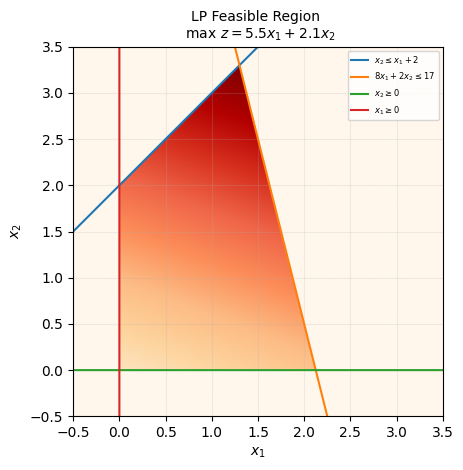

In [3]:
# Generate the feasible region plot of this problem

# Define meshgrid for feasible region
d = np.linspace(-0.5,3.5,300)
x1,x2 = np.meshgrid(d,d)

# Define the lines for the constraints
x = np.linspace(x1.min(), x1.max(), 2000)
# x2 <= x1 + 2
x21 = x + 2
# 8*x1 + 2*x2 <= 17
x22 = (17-8*x)/2.0
# obj: max 5.5x1 + 2.1x2
Z = 5.5*x1 + 2.1*x2

# generate heatmap from objective function
objective_heatmap = np.fromfunction(lambda i, j:5.5 * i + 2.1 * j,(300,300), dtype=float)

# Plot feasible region
fig, ax = plt.subplots()
feas_reg = ax.imshow( (
    (x1>=0) &           # Bound 1 
    (x2>=0) &           # Bound 2
    (x2 <= x1 + 2) &    # Constraint 1
    (8*x1 + 2*x2 <= 17) # Constraint 2
    ).astype(int) 
    * objective_heatmap, # objective function
                extent=(x1.min(),x1.max(),x2.min(),x2.max()),origin="lower", cmap="OrRd", alpha = 1, zorder=0)

# Make plots of constraints
ax.plot(x, x21, label=r'$x_2 \leq x_1 + 2$', zorder=2)
ax.plot(x, x22, label=r'$8x_1 + 2x_2 \leq 17$', zorder=2)

# Nonnegativitivy constraints
ax.plot(x, np.zeros_like(x), label=r'$x_2 \geq 0$', zorder=2)
ax.plot(np.zeros_like(x), x, label=r'$x_1 \geq 0$', zorder=2)

# plot formatting
plt.title("LP Feasible Region \n max $z = 5.5x_{1} + 2.1x_{2}$",fontsize=10,y=1)
plt.xlim(x1.min(),x1.max())
plt.ylim(x2.min(),x2.max())
plt.legend(loc='upper right', prop={'size': 6})
plt.xlabel(r'$x_1$')
plt.ylabel(r'$x_2$')
plt.grid(alpha=0.2)


In [4]:
# Define the model
model = pyo.ConcreteModel(name='Simple example LP')
# Define the variables
model.x = pyo.Var([1,2], domain=pyo.NonNegativeReals)
# Define the objective function
def _obj(m):
    return 5.5*m.x[1] + 2.1*m.x[2]

model.obj = pyo.Objective(rule = _obj, sense=pyo.maximize)
# Define the constraints
def _constraint1(m):
    return m.x[2] <= m.x[1] + 2

def _constraint2(m):
    return 8*m.x[1] + 2*m.x[2] <= 17
    
model.Constraint1 = pyo.Constraint(rule = _constraint1)

model.Constraint2 = pyo.Constraint(rule = _constraint2)
# Print the model
model.pprint()

1 Var Declarations
    x : Size=2, Index={1, 2}
        Key : Lower : Value : Upper : Fixed : Stale : Domain
          1 :     0 :  None :  None : False :  True : NonNegativeReals
          2 :     0 :  None :  None : False :  True : NonNegativeReals

1 Objective Declarations
    obj : Size=1, Index=None, Active=True
        Key  : Active : Sense    : Expression
        None :   True : maximize : 5.5*x[1] + 2.1*x[2]

2 Constraint Declarations
    Constraint1 : Size=1, Index=None, Active=True
        Key  : Lower : Body              : Upper : Active
        None :  -Inf : x[2] - (x[1] + 2) :   0.0 :   True
    Constraint2 : Size=1, Index=None, Active=True
        Key  : Lower : Body            : Upper : Active
        None :  -Inf : 8*x[1] + 2*x[2] :  17.0 :   True

4 Declarations: x obj Constraint1 Constraint2


In [5]:
# No extra LP solver installation is needed here because HiGHS is installed as a Python package.
print("Using the HiGHS Python interface for the LP/MILP solves in this notebook.")


Using the HiGHS Python interface for the LP/MILP solves in this notebook.


In [6]:
# Define the HiGHS solver used for the LP and MILP examples
opt_highs = Highs()
# Here we could use another solver, e.g. gurobi or cplex
# opt_gurobi = pyo.SolverFactory('gurobi')


In [7]:
# Here we solve the optimization problem, the option tee=True prints the solver output
result_obj = opt_highs.solve(model, tee=True)

In [8]:
# Display solution of the problem
model.display()

Model Simple example LP

  Variables:
    x : Size=2, Index={1, 2}
        Key : Lower : Value              : Upper : Fixed : Stale : Domain
          1 :     0 : 1.2999999999999998 :  None : False : False : NonNegativeReals
          2 :     0 :                3.3 :  None : False : False : NonNegativeReals

  Objectives:
    obj : Size=1, Index=None, Active=True
        Key  : Active : Value
        None :   True : 14.079999999999998

  Constraints:
    Constraint1 : Size=1
        Key  : Lower : Body : Upper
        None :  None :  0.0 :   0.0
    Constraint2 : Size=1
        Key  : Lower : Body : Upper
        None :  None : 17.0 :  17.0


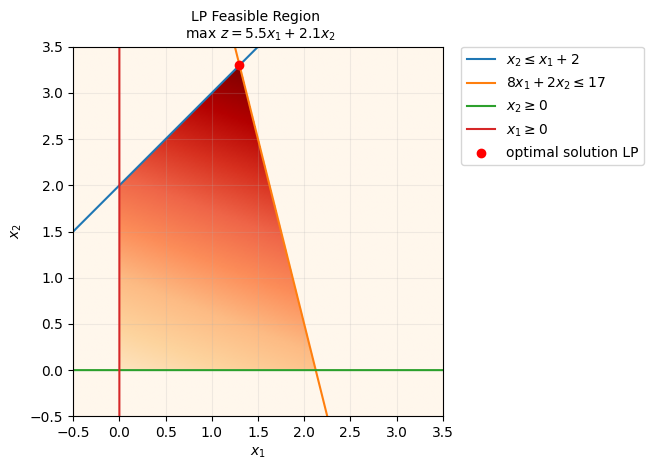

In [9]:
# Optimal solution LP
ax.scatter(1.3,3.3,color='r', label='optimal solution LP', zorder=5)
ax.get_legend().remove()
ax.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
fig.canvas.draw()
fig

We observe that the optimal solution of this problem is $(x_1, x_2) = (1.3, 3.3)$, leading to a profit of $14.08$.


In [10]:
# Display the LP solution returned by HiGHS
model.display()


Model Simple example LP

  Variables:
    x : Size=2, Index={1, 2}
        Key : Lower : Value              : Upper : Fixed : Stale : Domain
          1 :     0 : 1.2999999999999998 :  None : False : False : NonNegativeReals
          2 :     0 :                3.3 :  None : False : False : NonNegativeReals

  Objectives:
    obj : Size=1, Index=None, Active=True
        Key  : Active : Value
        None :   True : 14.079999999999998

  Constraints:
    Constraint1 : Size=1
        Key  : Lower : Body : Upper
        None :  None :  0.0 :   0.0
    Constraint2 : Size=1
        Key  : Lower : Body : Upper
        None :  None : 17.0 :  17.0


HiGHS recovers the LP optimum for this model and is the default open-source LP/MIP solver used in this notebook. We can also solve the LP relaxation with the interior-point solver IPOPT, which extends naturally to nonlinear programs. In mixed-integer models, however, IPOPT alone is not enough because it does not enforce integrality.


In [11]:
# Define helpers for IDAES-distributed NLP/MINLP solvers
SOLVER_DIR = "/content/solvers" if IN_COLAB else os.path.join(os.getcwd(), ".idaes")

def ensure_idaes_executable(name):
    solver_path = os.path.join(SOLVER_DIR, name)
    if os.path.exists(solver_path):
        os.environ["PATH"] += os.pathsep + SOLVER_DIR
        return solver_path

    on_path = shutil.which(name)
    if on_path is not None:
        return on_path

    if module_missing("idaes"):
        pip_install(["idaes-pse"])

    os.makedirs(SOLVER_DIR, exist_ok=True)
    run_command(["idaes", "get-extensions", "--to", SOLVER_DIR])
    os.environ["PATH"] += os.pathsep + SOLVER_DIR

    if os.path.exists(solver_path):
        return solver_path

    return shutil.which(name)


# Define the solver IPOPT
ipopt_executable = ensure_idaes_executable("ipopt")
if ipopt_executable is not None:
    opt_ipopt = pyo.SolverFactory("ipopt", executable=ipopt_executable)
else:
    opt_ipopt = pyo.SolverFactory("ipopt")


In [12]:
# Here we solve the optimization problem, the option tee=True prints the solver output
result_obj_ipopt = opt_ipopt.solve(model, tee=True)
model.display()

Ipopt 3.13.2: 

******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit http://projects.coin-or.org/Ipopt

This version of Ipopt was compiled from source code available at
    https://github.com/IDAES/Ipopt as part of the Institute for the Design of
    Advanced Energy Systems Process Systems Engineering Framework (IDAES PSE
    Framework) Copyright (c) 2018-2019. See https://github.com/IDAES/idaes-pse.

This version of Ipopt was compiled using HSL, a collection of Fortran codes
    for large-scale scientific computation.  All technical papers, sales and
    publicity material resulting from use of the HSL codes within IPOPT must
    contain the following acknowledgement:
        HSL, a collection of Fortran codes for large-scale scientific
        computation. See http://

Model Simple example LP

  Variables:
    x : Size=2, Index={1, 2}
        Key : Lower : Value              : Upper : Fixed : Stale : Domain
          1 :     0 : 1.3000000135344931 :  None : False : False : NonNegativeReals
          2 :     0 :   3.30000002921309 :  None : False : False : NonNegativeReals

  Objectives:
    obj : Size=1, Index=None, Active=True
        Key  : Active : Value
        None :   True : 14.080000135787202

  Constraints:
    Constraint1 : Size=1
        Key  : Lower : Body                  : Upper
        None :  None : 1.567859664319826e-08 :   0.0
    Constraint2 : Size=1
        Key  : Lower : Body               : Upper
        None :  None : 17.000000166702126 :  17.0


We obtain the same result as previously, but notice that the interior point method reports some solution subject to certain tolerance, given by its convergence properties when it can get infinitesimally close (but not directly at) the boundary of the feasible region.

The LP model is a useful baseline because it solves quickly, and it gives us a reference objective before we add nonlinear structure or impose integrality. It is also an upper bound on the later integer model.


### Nonlinear Programming
Before imposing integrality, we can add a convex nonlinear constraint while keeping the variables continuous. This gives the following nonlinear program (NLP):
$$
\begin{aligned}
\max_{x_1, x_2} \quad & 5.5x_1 + 2.1x_2 \\
\text{s.t.} \quad & x_2 \leq x_1 + 2 \\
& 8x_1 + 2x_2 \leq 17 \\
& (x_2-1)^2 \leq 2-x_1 \\
& x_1, x_2 \geq 0
\end{aligned}
$$


In [13]:
# Define the continuous nonlinear model
model_nlp = model.clone()
model_nlp.name = 'Simple example convex NLP, 47-779 QuIP'
model_nlp.Constraint3 = pyo.Constraint(expr=(model_nlp.x[2] - 1)**2 <= 2 - model_nlp.x[1])
model_nlp.pprint()


1 Var Declarations
    x : Size=2, Index={1, 2}
        Key : Lower : Value              : Upper : Fixed : Stale : Domain
          1 :     0 : 1.3000000135344931 :  None : False : False : NonNegativeReals
          2 :     0 :   3.30000002921309 :  None : False : False : NonNegativeReals

1 Objective Declarations
    obj : Size=1, Index=None, Active=True
        Key  : Active : Sense    : Expression
        None :   True : maximize : 5.5*x[1] + 2.1*x[2]

3 Constraint Declarations
    Constraint1 : Size=1, Index=None, Active=True
        Key  : Lower : Body              : Upper : Active
        None :  -Inf : x[2] - (x[1] + 2) :   0.0 :   True
    Constraint2 : Size=1, Index=None, Active=True
        Key  : Lower : Body            : Upper : Active
        None :  -Inf : 8*x[1] + 2*x[2] :  17.0 :   True
    Constraint3 : Size=1, Index=None, Active=True
        Key  : Lower : Body                       : Upper : Active
        None :  -Inf : (x[2] - 1)**2 - (2 - x[1]) :   0.0 :   True

5

In [14]:
# Solve the nonlinear program with IPOPT
result_obj_nlp = opt_ipopt.solve(model_nlp, tee=False)
model_nlp.display()


Model 'Simple example convex NLP, 47-779 QuIP'

  Variables:
    x : Size=2, Index={1, 2}
        Key : Lower : Value              : Upper : Fixed : Stale : Domain
          1 :     0 : 1.7500000217961182 :  None : False : False : NonNegativeReals
          2 :     0 :  1.499999995605554 :  None : False : False : NonNegativeReals

  Objectives:
    obj : Size=1, Index=None, Active=True
        Key  : Active : Value
        None :   True : 12.775000110650314

  Constraints:
    Constraint1 : Size=1
        Key  : Lower : Body                : Upper
        None :  None : -2.2500000261905644 :   0.0
    Constraint2 : Size=1
        Key  : Lower : Body               : Upper
        None :  None : 17.000000165580055 :  17.0
    Constraint3 : Size=1
        Key  : Lower : Body                   : Upper
        None :  None : 1.7401672353090092e-08 :   0.0


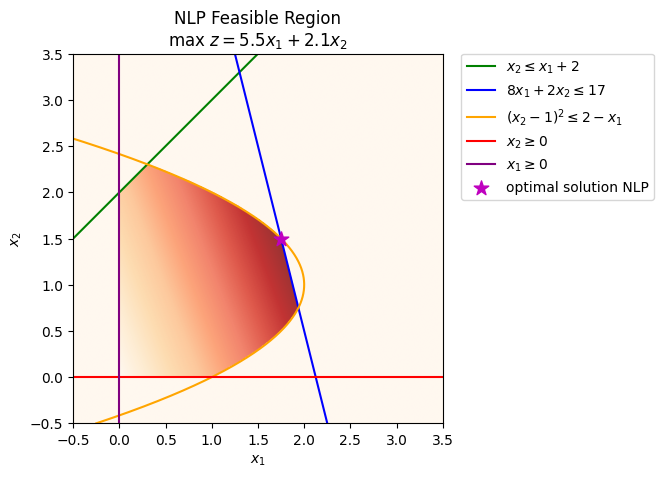

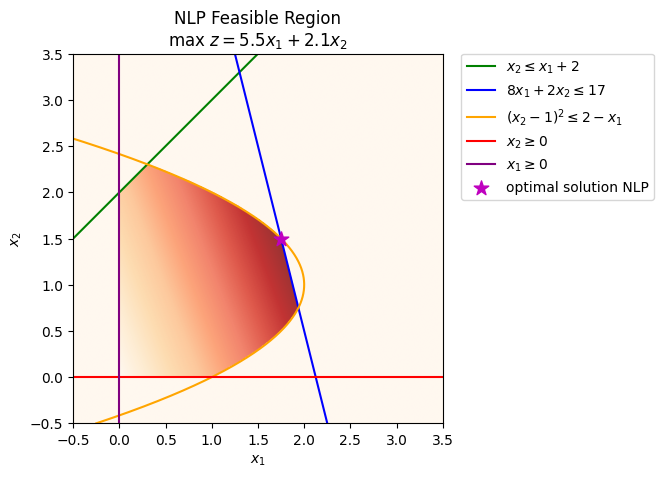

In [15]:
# Plot the feasible region of the nonlinear program
fig_nlp, ax_nlp = plt.subplots()
d_nlp = np.linspace(-0.5, 3.5, 400)
x1_nlp, x2_nlp = np.meshgrid(d_nlp, d_nlp)
x_nlp = np.linspace(d_nlp.min(), d_nlp.max(), 2000)
objective_heatmap_nlp = 5.5 * x1_nlp + 2.1 * x2_nlp
feasible_nlp = ((x1_nlp >= 0) & (x2_nlp >= 0) & (x2_nlp <= x1_nlp + 2) & (8 * x1_nlp + 2 * x2_nlp <= 17) & ((x2_nlp - 1)**2 <= 2 - x1_nlp))
ax_nlp.imshow(feasible_nlp.astype(int) * objective_heatmap_nlp, extent=(x1_nlp.min(), x1_nlp.max(), x2_nlp.min(), x2_nlp.max()), origin='lower', cmap='OrRd', alpha=.8, zorder=0)
ax_nlp.plot(x_nlp, x_nlp + 2, color='g', label=r'$x_2 \leq x_1 + 2$', zorder=2)
ax_nlp.plot(x_nlp, (17 - 8 * x_nlp) / 2.0, color='b', label=r'$8x_1 + 2x_2 \leq 17$', zorder=2)
ax_nlp.plot(2 - (x_nlp - 1)**2, x_nlp, color='orange', label=r'$(x_2-1)^2 \leq 2 - x_1$', zorder=2)
ax_nlp.axhline(0, color='r', label=r'$x_2 \geq 0$', zorder=2)
ax_nlp.axvline(0, color='purple', label=r'$x_1 \geq 0$', zorder=2)
ax_nlp.scatter(pyo.value(model_nlp.x[1]), pyo.value(model_nlp.x[2]), color='m', marker='*', s=120, label='optimal solution NLP', zorder=5)
ax_nlp.set_xlim(x1_nlp.min(), x1_nlp.max())
ax_nlp.set_ylim(x2_nlp.min(), x2_nlp.max())
ax_nlp.set_xlabel(r'$x_1$')
ax_nlp.set_ylabel(r'$x_2$')
ax_nlp.set_title('NLP Feasible Region\nmax $z = 5.5x_1 + 2.1x_2$')
ax_nlp.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
fig_nlp.canvas.draw()
fig_nlp


Here the continuous NLP solution is approximately $(x_1, x_2) = (1.75, 1.50)$ with objective $12.775$. Compared with the LP solution, the convex nonlinear constraint bends the feasible region and lowers the optimum, but the problem is still continuous because no integrality has been imposed yet.


### Integer Programming
Now let's consider that only integer units of each product can be produced, namely
$$
\begin{aligned}
\max_{x_1, x_2} \quad & 5.5x_1 + 2.1x_2 \\
\text{s.t.} \quad & x_2 \leq x_1 + 2 \\
& 8x_1 + 2x_2 \leq 17 \\
& x_1, x_2 \geq 0 \\
& x_1, x_2 \in \mathbb{Z}
\end{aligned}
$$


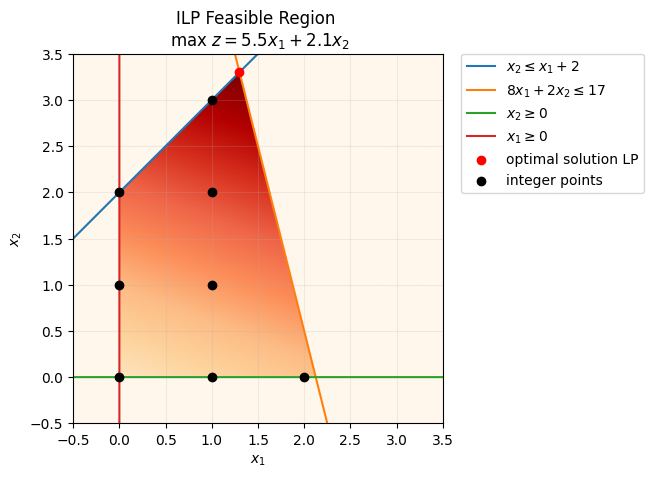

In [16]:
# Define grid for integer points
x1_int, x2_int = np.meshgrid(range(math.ceil(x1.max())), range(math.ceil(x2.max())))
idx = ((x1_int>=0) & (x2_int <= x1_int + 2) & (8*x1_int + 2*x2_int <= 17) & (x2_int>=0))
x1_int, x2_int = x1_int[idx], x2_int[idx]
ax.scatter(x1_int,x2_int,color='k', label='integer points', zorder=4)

# Plotting optimal solution IP
# plt.title("LP Feasible Region \n max $z = 5.5x_{1} + 2.1x_{2}$",fontsize=10,y=1)
ax.set_title("ILP Feasible Region \n max $z = 5.5x_{1} + 2.1x_{2}$")
ax.get_legend().remove()
ax.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
fig.canvas.draw()
fig

In [17]:
# Define the integer model
model_ilp = pyo.ConcreteModel(name='Simple example IP, 47-779 QuIP')
#Define the variables
model_ilp.x = pyo.Var([1,2], domain=pyo.Integers)
# Define the objective function
model_ilp.obj = pyo.Objective(rule = _obj, sense=pyo.maximize)
# Define the constraints
model_ilp.Constraint1 = pyo.Constraint(rule = _constraint1)

model_ilp.Constraint2 = pyo.Constraint(rule = _constraint2)
# Print the model
model_ilp.pprint()

1 Var Declarations
    x : Size=2, Index={1, 2}
        Key : Lower : Value : Upper : Fixed : Stale : Domain
          1 :  None :  None :  None : False :  True : Integers
          2 :  None :  None :  None : False :  True : Integers

1 Objective Declarations
    obj : Size=1, Index=None, Active=True
        Key  : Active : Sense    : Expression
        None :   True : maximize : 5.5*x[1] + 2.1*x[2]

2 Constraint Declarations
    Constraint1 : Size=1, Index=None, Active=True
        Key  : Lower : Body              : Upper : Active
        None :  -Inf : x[2] - (x[1] + 2) :   0.0 :   True
    Constraint2 : Size=1, Index=None, Active=True
        Key  : Lower : Body            : Upper : Active
        None :  -Inf : 8*x[1] + 2*x[2] :  17.0 :   True

4 Declarations: x obj Constraint1 Constraint2


In [18]:
# Here we solve the mixed-integer linear model with HiGHS
result_obj_ilp = opt_highs.solve(model_ilp)


In [19]:
model_ilp.display()

Model 'Simple example IP, 47-779 QuIP'

  Variables:
    x : Size=2, Index={1, 2}
        Key : Lower : Value : Upper : Fixed : Stale : Domain
          1 :  None :   1.0 :  None : False : False : Integers
          2 :  None :   3.0 :  None : False : False : Integers

  Objectives:
    obj : Size=1, Index=None, Active=True
        Key  : Active : Value
        None :   True :  11.8

  Constraints:
    Constraint1 : Size=1
        Key  : Lower : Body : Upper
        None :  None :  0.0 :   0.0
    Constraint2 : Size=1
        Key  : Lower : Body : Upper
        None :  None : 14.0 :  17.0


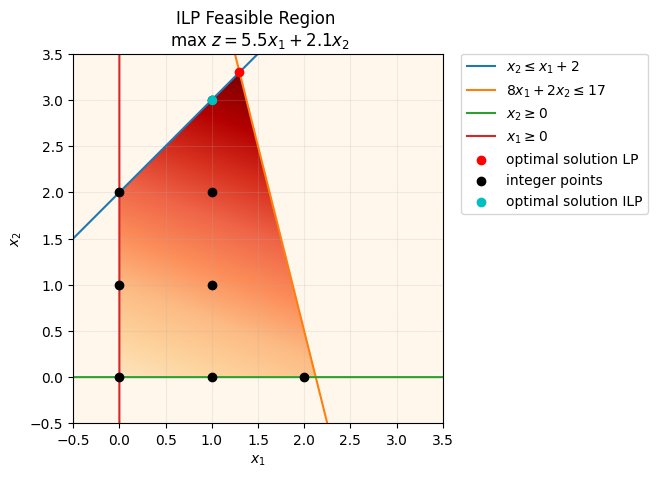

In [20]:
# Optimal solution ILP
ax.scatter(1,3,color='c', label='optimal solution ILP', zorder=5)
ax.get_legend().remove()
ax.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
fig.canvas.draw()
fig

Here the solution becomes $(x_1, x_2) = (1, 3)$ with an objective of $11.8$. Compared with the LP relaxation, the integer restriction shrinks the feasible set, so the best achievable profit is lower.


#### Enumeration
Enumerating all the possible solutions in this problem might be very efficient (there are only 8 feasible solutions), but we only know that from the plot. Assuming that the upper bounds for the variables were instead 4, the possible solutions would then be 16. With a larger number of variables, enumeration quickly becomes impractical. For $n$ binary variables (we can always "binarize" the integer variables), the number of possible solutions is $2^n$.

In many other applications, the possible solutions come from permutations of the integer variables (e.g. assignment problems), which grow as $n!$ with the size of the input.

This growth makes the problem grow out of control fairly quickly.


Text(0, 0.5, 'Possible solutions')

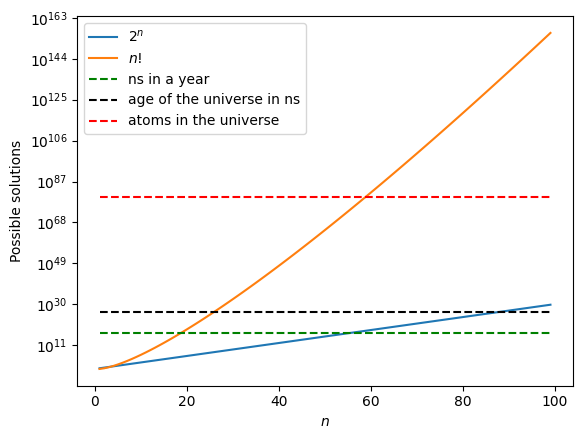

In [21]:
fig2, ax2 = plt.subplots()
n = np.arange(1,100,1)
ax2.plot(n,np.exp(n*np.log(2)), label=r'$2^n$')
ax2.plot(n,gamma(n + 1), label=r'$n!$')

ax2.plot(n,3.154E16*np.ones_like(n), 'g--', label=r'ns in a year')
ax2.plot(n,4.3E26*np.ones_like(n), 'k--', label=r'age of the universe in ns')
ax2.plot(n,6E79*np.ones_like(n), 'r--', label=r'atoms in the universe')
plt.yscale('log')

plt.legend()
plt.xlabel(r'$n$')
plt.ylabel('Possible solutions')


The growth plot highlights why brute-force enumeration stops scaling well even for modest binary or permutation-based optimization models.


### Integer convex nonlinear programming
If we keep the same convex nonlinear constraint and now require integer decisions, we obtain the following convex integer nonlinear program.
$$
\begin{aligned}
\max_{x_1, x_2} \quad & 5.5x_1 + 2.1x_2 \\
\text{s.t.} \quad & x_2 \leq x_1 + 2 \\
& 8x_1 + 2x_2 \leq 17 \\
& (x_2-1)^2 \leq 2-x_1 \\
& x_1, x_2 \geq 0 \\
& x_1, x_2 \in \mathbb{Z}
\end{aligned}
$$


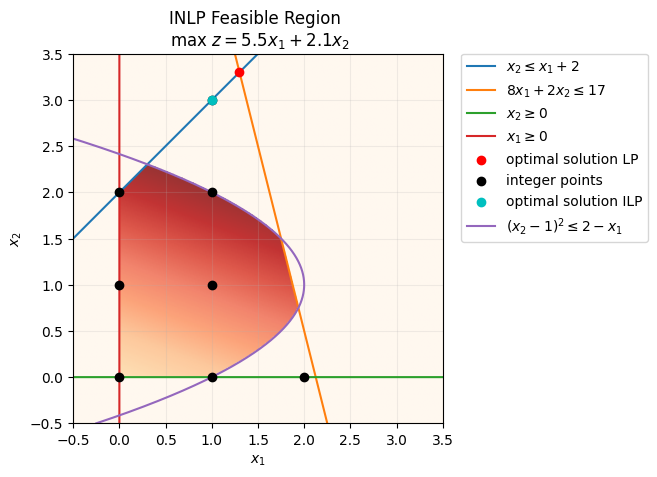

In [22]:
# Define grid for integer points
feas_reg.remove()
feas_reg = ax.imshow( (
    (x1>=0) &           # Bound 1 
    (x2>=0) &           # Bound 2
    (x2 <= x1 + 2) &    # Constraint 1
    (8*x1 + 2*x2 <= 17) & # Constraint 2
    ((x2-1)**2 <= 2-x1) # Nonlinear constraint
    ).astype(int) 
    * objective_heatmap, # objective function, 
                extent=(x1.min(),x1.max(),x2.min(),x2.max()),origin="lower", cmap="OrRd", alpha = .8, zorder=0)


x1nl = 2- (x - 1)**2
# Nonlinear constraint
nl_const = ax.plot(x1nl, x, label=r'$(x_2-1)^2 \leq 2-x_1$', zorder=2)

# Plotting optimal solution INLP
ax.set_title("INLP Feasible Region \n max $z = 5.5x_{1} + 2.1x_{2}$")
ax.get_legend().remove()
ax.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
fig.canvas.draw()
fig

In [23]:
# Define the integer model
model_cinlp = pyo.ConcreteModel(name='Simple example convex INLP, 47-779 QuIP')
#Define the variables
model_cinlp.x = pyo.Var([1,2], domain=pyo.Integers)
# Define the objective function
model_cinlp.obj = pyo.Objective(rule = _obj, sense=pyo.maximize)
# Define the constraints
model_cinlp.Constraint1 = pyo.Constraint(rule = _constraint1)

model_cinlp.Constraint2 = pyo.Constraint(rule = _constraint2)

model_cinlp.Constraint3 = pyo.Constraint(expr = (model_cinlp.x[2]-1)**2 <= 2 - model_cinlp.x[1])


# Print the model
model_cinlp.pprint()

1 Var Declarations
    x : Size=2, Index={1, 2}
        Key : Lower : Value : Upper : Fixed : Stale : Domain
          1 :  None :  None :  None : False :  True : Integers
          2 :  None :  None :  None : False :  True : Integers

1 Objective Declarations
    obj : Size=1, Index=None, Active=True
        Key  : Active : Sense    : Expression
        None :   True : maximize : 5.5*x[1] + 2.1*x[2]

3 Constraint Declarations
    Constraint1 : Size=1, Index=None, Active=True
        Key  : Lower : Body              : Upper : Active
        None :  -Inf : x[2] - (x[1] + 2) :   0.0 :   True
    Constraint2 : Size=1, Index=None, Active=True
        Key  : Lower : Body            : Upper : Active
        None :  -Inf : 8*x[1] + 2*x[2] :  17.0 :   True
    Constraint3 : Size=1, Index=None, Active=True
        Key  : Lower : Body                       : Upper : Active
        None :  -Inf : (x[2] - 1)**2 - (2 - x[1]) :   0.0 :   True

5 Declarations: x obj Constraint1 Constraint2 Constraint

In [24]:
# Define the solver BONMIN
bonmin_executable = ensure_idaes_executable('bonmin')
if bonmin_executable is not None:
    opt_bonmin = pyo.SolverFactory('bonmin', executable=bonmin_executable)
else:
    opt_bonmin = pyo.SolverFactory('bonmin')


In [25]:
# Here we solve the optimization problem, the option tee=True prints the solver output
result_obj_cinlp = opt_bonmin.solve(model_cinlp, tee=False)
model_cinlp.display()

Model 'Simple example convex INLP, 47-779 QuIP'

  Variables:
    x : Size=2, Index={1, 2}
        Key : Lower : Value : Upper : Fixed : Stale : Domain
          1 :  None :   1.0 :  None : False : False : Integers
          2 :  None :   2.0 :  None : False : False : Integers

  Objectives:
    obj : Size=1, Index=None, Active=True
        Key  : Active : Value
        None :   True :   9.7

  Constraints:
    Constraint1 : Size=1
        Key  : Lower : Body : Upper
        None :  None : -1.0 :   0.0
    Constraint2 : Size=1
        Key  : Lower : Body : Upper
        None :  None : 12.0 :  17.0
    Constraint3 : Size=1
        Key  : Lower : Body : Upper
        None :  None :  0.0 :   0.0


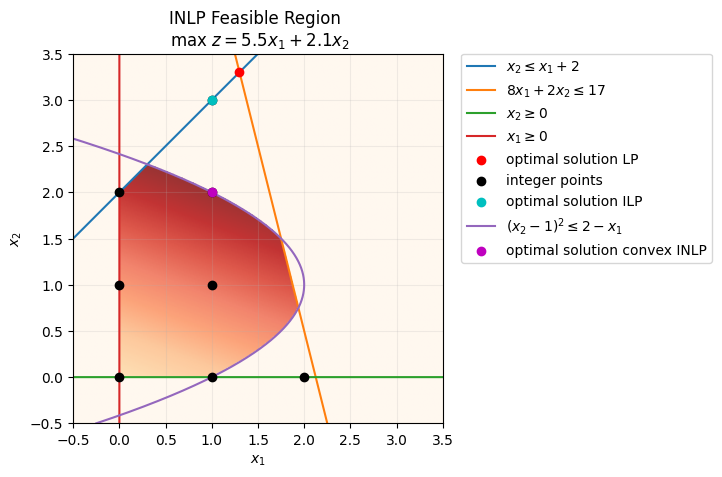

In [26]:
ax.scatter(1,2,color='m', label='optimal solution convex INLP', zorder=5)
ax.get_legend().remove()
ax.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
fig.canvas.draw()
fig

In this case the optimal solution becomes $(x_1, x_2) = (1, 2)$ with an objective of $9.7$. Compared with the continuous NLP, the same nonlinear geometry is still present, but the integer restriction removes the fractional optimum and lowers the best achievable profit again.


### Integer non-convex programming
The last constraint "the production of B minus 1 squared can only be greater than the production of A plus one half" can be incorporated in the following non-convex integer nonlinear program
$$
\begin{aligned}
\max_{x_1, x_2} \quad & 5.5x_1 + 2.1x_2 \\
\text{s.t.} \quad & x_2 \leq x_1 + 2 \\
& 8x_1 + 2x_2 \leq 17 \\
& (x_2-1)^2 \leq 2-x_1 \\
& (x_2-1)^2 \geq 1/2+x_1 \\
& x_1, x_2 \geq 0 \\
& x_1, x_2 \in \mathbb{Z}
\end{aligned}
$$


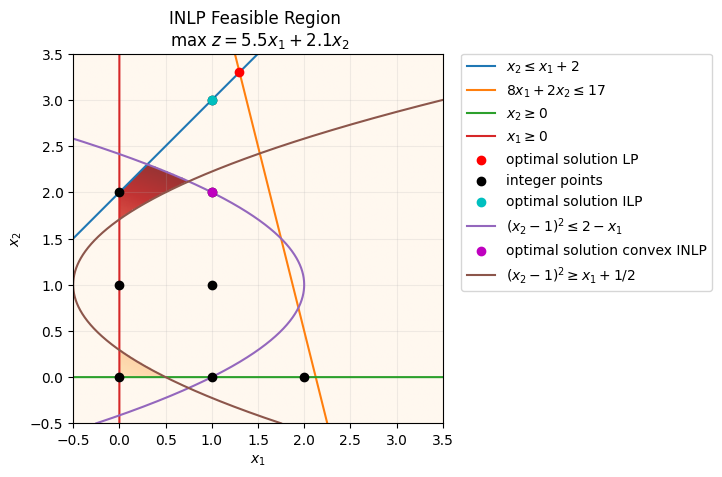

In [27]:
# Define grid for integer points
feas_reg.remove()
feas_reg = ax.imshow( (
    (x1>=0) &           # Bound 1 
    (x2>=0) &           # Bound 2
    (x2 <= x1 + 2) &    # Constraint 1
    (8*x1 + 2*x2 <= 17) & # Constraint 2
    ((x2-1)**2 <= 2-x1) & # Nonlinear constraint 1
    ((x2-1)**2 >= x1+0.5) # Nonlinear constraint 2
    ).astype(int) 
    * objective_heatmap,  # objective function,
                extent=(x1.min(),x1.max(),x2.min(),x2.max()),origin="lower", cmap="OrRd", alpha = .8, zorder=0)


x1nl = -1/2 + (x - 1)**2
# Nonlinear constraint
nl_const = ax.plot(x1nl, x, label=r'$(x_2-1)^2 \geq x_1 + 1/2$', zorder=2)

ax.get_legend().remove()
ax.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
fig.canvas.draw()
fig

In [28]:
# Define the integer model
model_ncinlp = pyo.ConcreteModel(name='Simple example non-convex INP, 47-779 QuIP')
#Define the variables
model_ncinlp.x = pyo.Var([1,2], domain=pyo.Integers)
# Define the objective function
model_ncinlp.obj = pyo.Objective(rule = _obj, sense=pyo.maximize)
# Define the constraints
model_ncinlp.Constraint1 = pyo.Constraint(rule = _constraint1)

model_ncinlp.Constraint2 = pyo.Constraint(rule = _constraint2)

model_ncinlp.Constraint3 = pyo.Constraint(expr = (model_ncinlp.x[2]-1)**2 <= 2 - model_ncinlp.x[1])

model_ncinlp.Constraint4 = pyo.Constraint(expr = (model_ncinlp.x[2]-1)**2 >= 1/2 + model_ncinlp.x[1])


# Print the model
model_ncinlp.pprint()

1 Var Declarations
    x : Size=2, Index={1, 2}
        Key : Lower : Value : Upper : Fixed : Stale : Domain
          1 :  None :  None :  None : False :  True : Integers
          2 :  None :  None :  None : False :  True : Integers

1 Objective Declarations
    obj : Size=1, Index=None, Active=True
        Key  : Active : Sense    : Expression
        None :   True : maximize : 5.5*x[1] + 2.1*x[2]

4 Constraint Declarations
    Constraint1 : Size=1, Index=None, Active=True
        Key  : Lower : Body              : Upper : Active
        None :  -Inf : x[2] - (x[1] + 2) :   0.0 :   True
    Constraint2 : Size=1, Index=None, Active=True
        Key  : Lower : Body            : Upper : Active
        None :  -Inf : 8*x[1] + 2*x[2] :  17.0 :   True
    Constraint3 : Size=1, Index=None, Active=True
        Key  : Lower : Body                       : Upper : Active
        None :  -Inf : (x[2] - 1)**2 - (2 - x[1]) :   0.0 :   True
    Constraint4 : Size=1, Index=None, Active=True
       

In [29]:
# Trying to solve the problem with BONMIN we might obtain a good solution, but we have no global guarantees
result_obj_ncinlp = opt_bonmin.solve(model_ncinlp, tee=False)
model_ncinlp.display()


Model 'Simple example non-convex INP, 47-779 QuIP'

  Variables:
    x : Size=2, Index={1, 2}
        Key : Lower : Value : Upper : Fixed : Stale : Domain
          1 :  None :   0.0 :  None : False : False : Integers
          2 :  None :   2.0 :  None : False : False : Integers

  Objectives:
    obj : Size=1, Index=None, Active=True
        Key  : Active : Value
        None :   True :   4.2

  Constraints:
    Constraint1 : Size=1
        Key  : Lower : Body : Upper
        None :  None :  0.0 :   0.0
    Constraint2 : Size=1
        Key  : Lower : Body : Upper
        None :  None :  4.0 :  17.0
    Constraint3 : Size=1
        Key  : Lower : Body : Upper
        None :  None : -1.0 :   0.0
    Constraint4 : Size=1
        Key  : Lower : Body : Upper
        None :  None : -0.5 :   0.0


In [30]:
# Define the solver COUENNE
couenne_executable = ensure_idaes_executable('couenne')
if couenne_executable is not None:
    opt_couenne = pyo.SolverFactory('couenne', executable=couenne_executable)
else:
    opt_couenne = pyo.SolverFactory('couenne')


In [31]:
# Solve the global MINLP with COUENNE
result_obj_ncinlp = opt_couenne.solve(model_ncinlp, tee=False)
model_ncinlp.display()


Model 'Simple example non-convex INP, 47-779 QuIP'

  Variables:
    x : Size=2, Index={1, 2}
        Key : Lower : Value : Upper : Fixed : Stale : Domain
          1 :  None :   0.0 :  None : False : False : Integers
          2 :  None :   2.0 :  None : False : False : Integers

  Objectives:
    obj : Size=1, Index=None, Active=True
        Key  : Active : Value
        None :   True :   4.2

  Constraints:
    Constraint1 : Size=1
        Key  : Lower : Body : Upper
        None :  None :  0.0 :   0.0
    Constraint2 : Size=1
        Key  : Lower : Body : Upper
        None :  None :  4.0 :  17.0
    Constraint3 : Size=1
        Key  : Lower : Body : Upper
        None :  None : -1.0 :   0.0
    Constraint4 : Size=1
        Key  : Lower : Body : Upper
        None :  None : -0.5 :   0.0


In [32]:
# Solve the same global MINLP directly with SCIP
scip_model = ScipModel('Simple example non-convex INP, 47-779 QuIP')
x1_scip = scip_model.addVar('x1', vtype='I', lb=0)
x2_scip = scip_model.addVar('x2', vtype='I', lb=0)

scip_model.setObjective(5.5 * x1_scip + 2.1 * x2_scip, 'maximize')
scip_model.addCons(x2_scip <= x1_scip + 2)
scip_model.addCons(8 * x1_scip + 2 * x2_scip <= 17)
scip_model.addCons((x2_scip - 1) * (x2_scip - 1) <= 2 - x1_scip)
scip_model.addCons((x2_scip - 1) * (x2_scip - 1) >= 0.5 + x1_scip)

scip_model.hideOutput()
scip_model.optimize()

print(f'SCIP status: {scip_model.getStatus()}')
if scip_model.getNSols() > 0:
    scip_solution = (scip_model.getVal(x1_scip), scip_model.getVal(x2_scip))
    scip_objective = scip_model.getObjVal()
    print(f'x = {scip_solution}')
    print(f'objective = {scip_objective:.1f}')


SCIP status: optimal
x = (-0.0, 2.0)
objective = 4.2


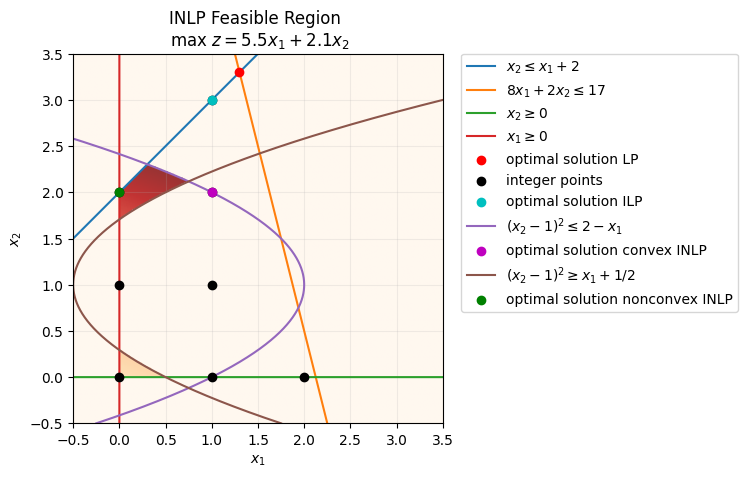

In [33]:
ax.scatter(0,2,color='g', label='optimal solution nonconvex INLP', zorder=5)
ax.get_legend().remove()
ax.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
fig.canvas.draw()
fig

BONMIN may return a good feasible point for this non-convex MINLP, but it does not provide a global certificate here. COUENNE and SCIP both recover the global optimum $(x_1, x_2) = (0, 2)$, with objective $4.2$. This is the first section where solver guarantees become central: a local answer is not enough.


## References
- [Pyomo](http://www.pyomo.org/)
- [HiGHS](https://highs.dev/)
- [SCIP](https://www.scipopt.org/)


### Commercial solver installation

#### Gurobi
Gurobi offers free academic licenses for students, faculty, and staff at recognized degree-granting institutions, and the current academic options include named-user, WLS, and site-license workflows. Because license types and setup steps change over time, use the current official pages for both eligibility and installation details:
- Academic licenses: https://www.gurobi.com/features/academic-cloud-license/
- License setup: https://support.gurobi.com/hc/en-us/articles/12872879801105-How-do-I-retrieve-and-set-up-a-Gurobi-license

#### BARON
BARON remains a leading global MINLP solver, but its academic licensing is more restrictive: most academic users use discounted academic pricing, while free licenses are limited to specific partner-university programs listed on the vendor site. Since these terms can change, check the current license and FAQ pages before planning coursework around BARON:
- Licenses: https://minlp.com/baron-licenses
- FAQ: https://minlp.com/baron-frequently-asked-questions
